In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

import xgboost as xgb

In [3]:
# Load the cleaned CICIDS2017 dataset (already preprocessed and label-encoded)
df = pd.read_csv("data/cleaned.csv")
print(f"Shape: {df.shape}")
print()
print(df.head())

Shape: (2520798, 79)

   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6             

In [4]:
# Class distribution
print("Class distribution:")
print(df["Label"].value_counts())

Class distribution:
Label
0     2095057
4      172846
2      128014
10      90694
3       10286
7        5931
6        5385
5        5228
11       3219
1        1948
12       1470
14        652
9          36
13         21
8          11
Name: count, dtype: int64


In [5]:
# Split features and target
X = df.drop(columns=["Label"])
y = df["Label"]

feature_names = X.columns.tolist()

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (2016638, 78), Test: (504160, 78)


In [6]:
# Compute sample weights to handle class imbalance
# (gives higher weight to rare attack types)
class_counts = y_train.value_counts()
total = len(y_train)
n_classes = len(class_counts)
class_weight_map = {c: total / (n_classes * count) for c, count in class_counts.items()}
sample_weights = y_train.map(class_weight_map)

print("Class weights:")
for c, w in sorted(class_weight_map.items()):
    print(f"  class {c}: {w:.4f}")

Class weights:
  class 0: 0.0802
  class 1: 86.2917
  class 2: 1.3128
  class 3: 16.3377
  class 4: 0.9723
  class 5: 32.1479
  class 6: 31.2076
  class 7: 28.3335
  class 8: 14938.0593
  class 9: 4635.9494
  class 10: 1.8530
  class 11: 52.2107
  class 12: 114.3219
  class 13: 7908.3843
  class 14: 257.5527


In [7]:
# ====================== BASELINE XGBoost ======================
print("=== BASELINE XGBoost ===")

model = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=n_classes,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42,
    eval_metric="mlogloss"
)

model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred))

=== BASELINE XGBoost ===
Accuracy : 0.9949
F1 (macro): 0.7936
ROC AUC  : 0.9999

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    419012
           1       0.27      1.00      0.43       390
           2       1.00      1.00      1.00     25603
           3       0.95      1.00      0.97      2057
           4       0.98      1.00      0.99     34569
           5       0.94      1.00      0.97      1046
           6       0.99      0.99      0.99      1077
           7       0.99      1.00      1.00      1186
           8       0.67      1.00      0.80         2
           9       0.33      1.00      0.50         7
          10       0.99      1.00      0.99     18139
          11       0.99      1.00      0.99       644
          12       0.63      0.64      0.64       294
          13       0.17      1.00      0.29         4
          14       0.24      0.75      0.36       130

    accuracy                           0.99    504160

In [8]:
%pip install optuna -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
import optuna

# ====================== OPTUNA HYPERPARAMETER TUNING ======================
print("=== STARTING OPTUNA TUNING ===")

# Stratified subsample 15% of training data for faster tuning
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, train_size=0.15, random_state=42)
tune_idx, _ = next(sss.split(X_train, y_train))
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]
sw_tune = sample_weights.iloc[tune_idx]
print(f"Tuning on {len(X_tune):,} rows (15% of train, stratified)")

def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 7),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5.0),
        "objective": "multi:softprob",
        "num_class": n_classes,
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "verbosity": 0,
        "early_stopping_rounds": 30,
    }

    clf = xgb.XGBClassifier(**params)
    clf.fit(
        X_tune, y_tune,
        sample_weight=sw_tune,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

    y_prob = clf.predict_proba(X_test)
    return roc_auc_score(y_test, y_prob, multi_class="ovr", average="macro")


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print(f"Best ROC AUC: {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

=== STARTING OPTUNA TUNING ===


/home/vss/Dropbox/Skole/KEA/Datamatiker/Semester 4/ml/ml-sem4/_eksamen/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-28 14:26:02,811] A new study created in memory with name: no-name-0392bae1-8aad-4c6e-b9e1-eff9e40c2528


Tuning on 302,495 rows (15% of train, stratified)


[I 2026-03-28 14:26:55,007] Trial 0 finished with value: 0.9995737026962278 and parameters: {'n_estimators': 432, 'max_depth': 4, 'learning_rate': 0.05923852118467913, 'subsample': 0.7023143032332433, 'colsample_bytree': 0.6429314690033405, 'gamma': 1.2038094446606546, 'reg_lambda': 6.855373656426358, 'reg_alpha': 3.173680619186738}. Best is trial 0 with value: 0.9995737026962278.
[I 2026-03-28 14:27:25,940] Trial 1 finished with value: 0.9996590480873268 and parameters: {'n_estimators': 249, 'max_depth': 3, 'learning_rate': 0.12937228704428658, 'subsample': 0.8719569448384368, 'colsample_bytree': 0.9322544005013538, 'gamma': 1.300133122119399, 'reg_lambda': 1.4686959193081048, 'reg_alpha': 0.010223802502450918}. Best is trial 1 with value: 0.9996590480873268.
[I 2026-03-28 14:27:52,509] Trial 2 finished with value: 0.9996315232119741 and parameters: {'n_estimators': 144, 'max_depth': 7, 'learning_rate': 0.03496303632912278, 'subsample': 0.6116326465010503, 'colsample_bytree': 0.895134

Best ROC AUC: 0.9997
Best parameters: {'n_estimators': 249, 'max_depth': 3, 'learning_rate': 0.12937228704428658, 'subsample': 0.8719569448384368, 'colsample_bytree': 0.9322544005013538, 'gamma': 1.300133122119399, 'reg_lambda': 1.4686959193081048, 'reg_alpha': 0.010223802502450918}


In [16]:
# ====================== FINAL OPTIMIZED MODEL ======================
print("=== FINAL OPTIMIZED XGBoost ===")

best_params = study.best_params
best_params.update({
    "objective": "multi:softprob",
    "num_class": n_classes,
    "eval_metric": "mlogloss",
    "random_state": 42,
    "verbosity": 0,
})

final_model = xgb.XGBClassifier(**best_params)
final_model.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)

print(f"Accuracy  : {accuracy_score(y_test, y_pred_final):.4f}")
print(f"F1 (macro): {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"ROC AUC   : {roc_auc_score(y_test, y_prob_final, multi_class='ovr', average='macro'):.4f}")
print()
print(classification_report(y_test, y_pred_final))

=== FINAL OPTIMIZED XGBoost ===
Accuracy  : 0.9979
F1 (macro): 0.8591
ROC AUC   : 0.9999

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    419012
           1       0.54      1.00      0.70       390
           2       1.00      1.00      1.00     25603
           3       0.98      1.00      0.99      2057
           4       1.00      1.00      1.00     34569
           5       0.95      1.00      0.97      1046
           6       0.98      0.99      0.99      1077
           7       0.99      1.00      1.00      1186
           8       0.67      1.00      0.80         2
           9       0.58      1.00      0.74         7
          10       0.99      1.00      0.99     18139
          11       0.99      1.00      1.00       644
          12       0.76      0.70      0.73       294
          13       0.40      1.00      0.57         4
          14       0.30      0.67      0.42       130

    accuracy                           1.00 

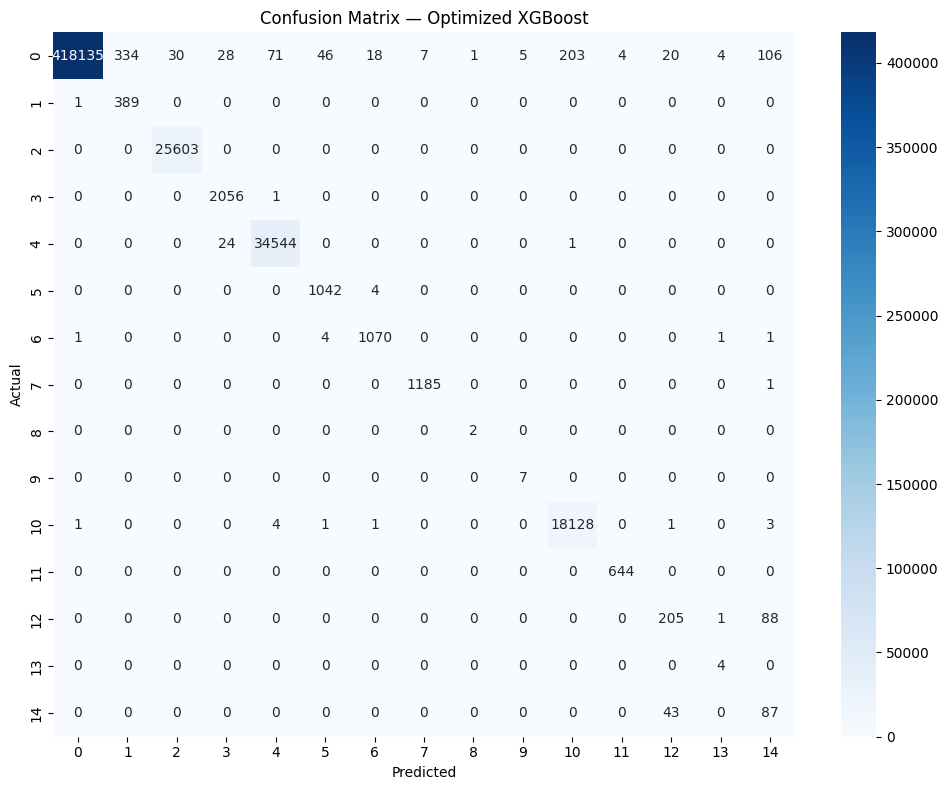

In [17]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Optimized XGBoost")
plt.tight_layout()
plt.show()

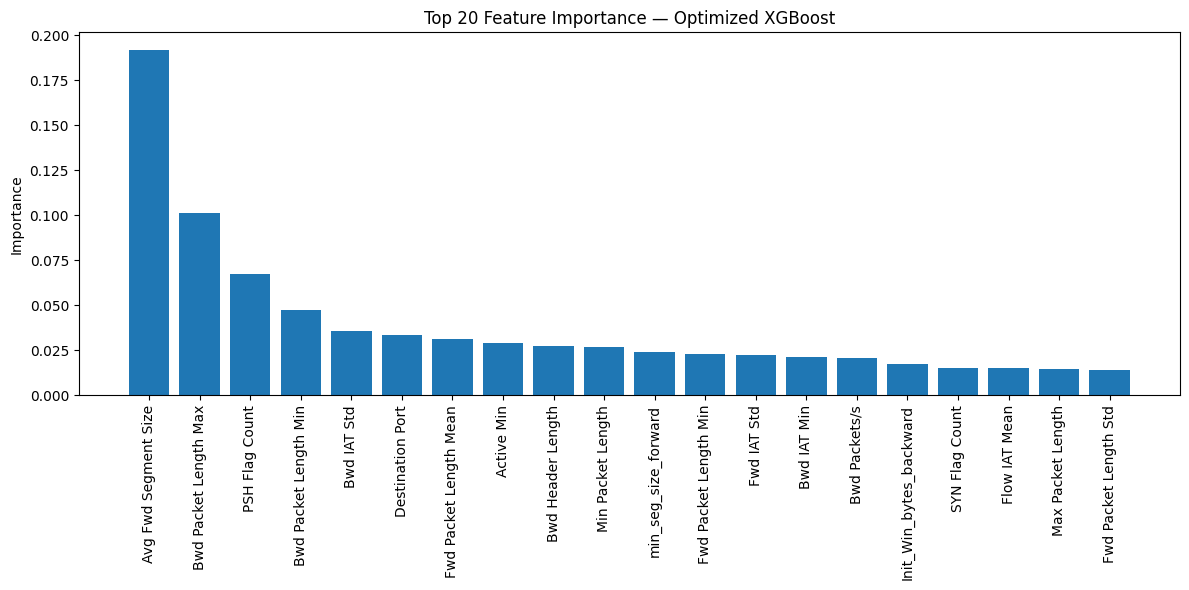

In [18]:
# Feature importance (top 20)
importances = final_model.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(12, 6))
plt.title("Top 20 Feature Importance — Optimized XGBoost")
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=90)
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

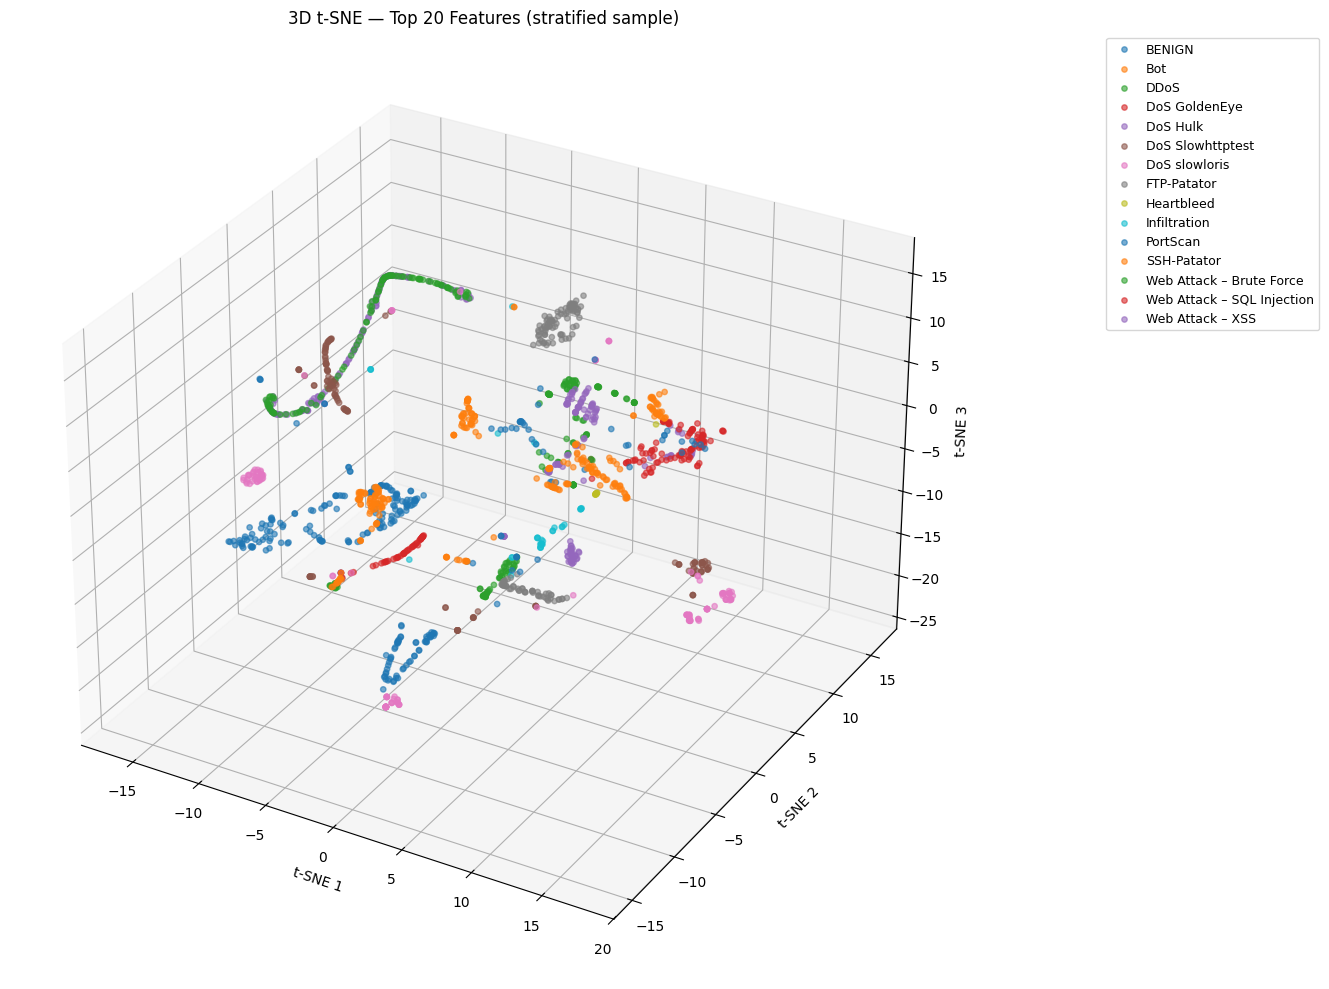

In [19]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# t-SNE on a stratified sample (2000 points — t-SNE is O(n²))
label_names = {
    0: "BENIGN", 1: "Bot", 2: "DDoS", 3: "DoS GoldenEye",
    4: "DoS Hulk", 5: "DoS Slowhttptest", 6: "DoS slowloris",
    7: "FTP-Patator", 8: "Heartbleed", 9: "Infiltration",
    10: "PortScan", 11: "SSH-Patator", 12: "Web Attack – Brute Force",
    13: "Web Attack – SQL Injection", 14: "Web Attack – XSS"
}

n_sample = 2000
sample_dfs = []
for label in y.unique():
    group = df[df["Label"] == label]
    n = min(len(group), max(n_sample // n_classes, 2))
    sample_dfs.append(group.sample(n=n, random_state=42))
tsne_df = pd.concat(sample_dfs)

X_tsne = tsne_df.drop(columns=["Label"])
y_tsne = tsne_df["Label"]

# Use top 20 features from the model for cleaner separation
top_features = [feature_names[i] for i in np.argsort(final_model.feature_importances_)[::-1][:20]]
X_tsne_top = X_tsne[top_features]

# Scale before t-SNE
X_scaled = StandardScaler().fit_transform(X_tsne_top)

# 3D t-SNE
tsne = TSNE(n_components=3, perplexity=30, random_state=42, max_iter=1000)
embedding = tsne.fit_transform(X_scaled)

# 3D scatter plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection="3d")
for label in sorted(y_tsne.unique()):
    mask = y_tsne.values == label
    ax.scatter(
        embedding[mask, 0], embedding[mask, 1], embedding[mask, 2],
        label=label_names.get(label, str(label)),
        s=15, alpha=0.6
    )
ax.legend(bbox_to_anchor=(1.15, 1), loc="upper left", fontsize=9)
ax.set_title("3D t-SNE — Top 20 Features (stratified sample)")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_zlabel("t-SNE 3")
plt.tight_layout()
plt.show()

In [20]:
%pip install plotly nbformat -q

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, json
from skl2onnx import convert_sklearn, update_registered_converter
from skl2onnx.common.shape_calculator import calculate_linear_classifier_output_shapes
from onnxmltools.convert.xgboost.operator_converters.XGBoost import convert_xgboost
from skl2onnx.common.data_types import FloatTensorType

os.makedirs("../model", exist_ok=True)

# Register XGBoost converter for sklearn pipeline
update_registered_converter(
    xgb.XGBClassifier,
    "XGBoostXGBClassifier",
    calculate_linear_classifier_output_shapes,
    convert_xgboost,
    options={"nocl": [True, False], "zipmap": [True, False, "columns"]},
)

# Convert to ONNX
onnx_model = convert_sklearn(
    final_model,
    "flowwatch",
    [("input", FloatTensorType([None, len(feature_names)]))],
    target_opset=12,
    options={type(final_model): {"zipmap": False}},
)

with open("../model/flowwatch.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

# Save feature names and label mapping
metadata = {
    "feature_names": feature_names,
    "label_names": {str(k): v for k, v in label_names.items()}
}
with open("../model/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved model to ../model/flowwatch.onnx")
print("Saved metadata to ../model/metadata.json")